In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Fixed parameters
gamma = 0.5 # Host mortality rate
alpha = 0.04   # Shedding rate of pathogen by infected hosts
beta_d = 0.05  # Direct transmission rate
beta_i = 0.03  # Indirect transmission rate via environment


# Varying parameter (lower bound, higher bound, and resolution)
mu_range = np.linspace(0.01, 0.5, 100)

R0_values = []

for mu in mu_range:
    R0 = (beta_d / gamma) + (beta_i / gamma) * (alpha / mu)
    R0_values.append(R0) # List of exact R0 values

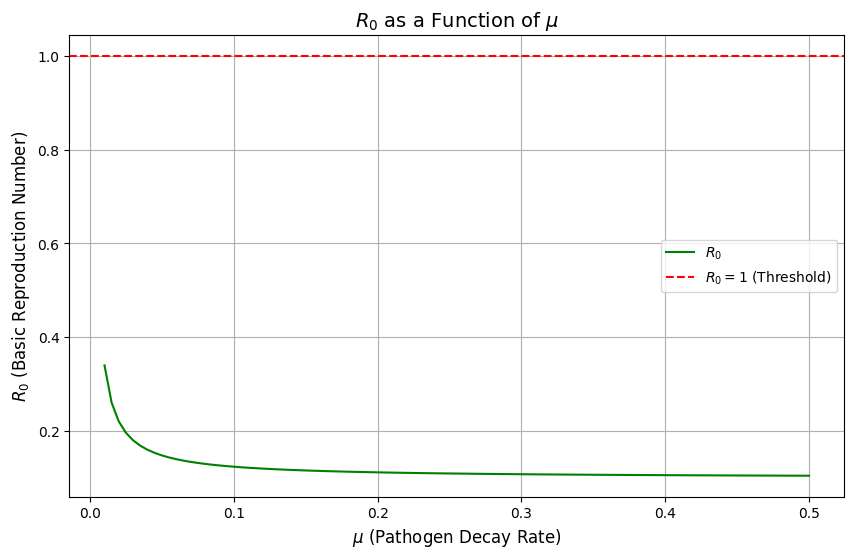

[(0.01, 0.34), (0.015, 0.261), (0.02, 0.221), (0.025, 0.197), (0.03, 0.181), (0.035, 0.169), (0.04, 0.16), (0.045, 0.154), (0.05, 0.148), (0.055, 0.144), (0.059, 0.14), (0.064, 0.137), (0.069, 0.135), (0.074, 0.132), (0.079, 0.13), (0.084, 0.128), (0.089, 0.127), (0.094, 0.125), (0.099, 0.124), (0.104, 0.123), (0.109, 0.122), (0.114, 0.121), (0.119, 0.12), (0.124, 0.119), (0.129, 0.119), (0.134, 0.118), (0.139, 0.117), (0.144, 0.117), (0.149, 0.116), (0.154, 0.116), (0.158, 0.115), (0.163, 0.115), (0.168, 0.114), (0.173, 0.114), (0.178, 0.113), (0.183, 0.113), (0.188, 0.113), (0.193, 0.112), (0.198, 0.112), (0.203, 0.112), (0.208, 0.112), (0.213, 0.111), (0.218, 0.111), (0.223, 0.111), (0.228, 0.111), (0.233, 0.11), (0.238, 0.11), (0.243, 0.11), (0.248, 0.11), (0.253, 0.11), (0.257, 0.109), (0.262, 0.109), (0.267, 0.109), (0.272, 0.109), (0.277, 0.109), (0.282, 0.109), (0.287, 0.108), (0.292, 0.108), (0.297, 0.108), (0.302, 0.108), (0.307, 0.108), (0.312, 0.108), (0.317, 0.108), (0.322

In [9]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(mu_range, R0_values, label=r'$R_0$', color='g')
plt.axhline(y=1, color='r', linestyle='--', label=r'$R_0 = 1$ (Threshold)')
plt.xlabel(r'$\mu$ (Pathogen Decay Rate)', fontsize=12)
plt.ylabel(r'$R_0$ (Basic Reproduction Number)', fontsize=12)
plt.title(r'$R_0$ as a Function of $\mu$', fontsize=14)
plt.legend()
plt.grid()
plt.show()

print([tuple((round(float(mu), 3), round(float(R0), 3))) for mu, R0 in zip(mu_range, R0_values)])

Fitted Equation: R0 ≈ 0.0024 / mu + 0.1000


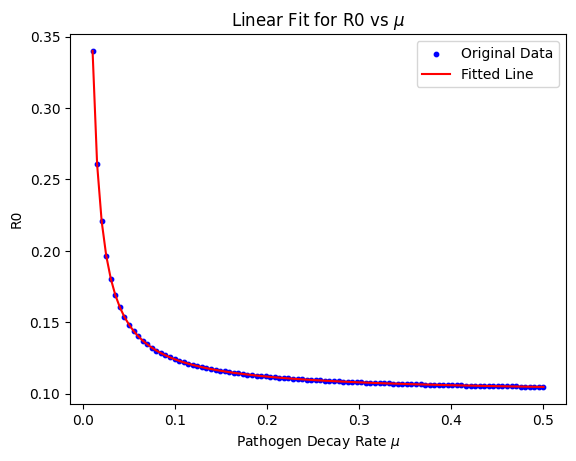

In [3]:
from scipy.optimize import curve_fit
# Define a function for curve fitting (inverse relationship)
def inverse_model(mu, a, b):
    return a / mu + b

# Fit the curve to the data
params, _ = curve_fit(inverse_model, mu_range, R0_values)

# Extract the best-fit parameters
a_fit, b_fit = params
print(f"Fitted Equation: R0 ≈ {a_fit:.4f} / mu + {b_fit:.4f}")

# Plot the original data and the fitted line
plt.scatter(mu_range, R0_values, label="Original Data", color="blue", s=10)
plt.plot(mu_range, inverse_model(mu_range, *params), label="Fitted Line", color="red")
plt.xlabel(r'Pathogen Decay Rate $\mu$')
plt.ylabel("R0")
plt.legend()
plt.title(r'Linear Fit for R0 vs $\mu$')
plt.show()